<a href="https://colab.research.google.com/github/jclugor/kl_psd/blob/main/notebooks/vae/VAE_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Pre-procesamiento base de datos**

In [60]:
# ============================================================
# Cell 0 — Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
# ============================================================
# Cell 1 — Config (input/output + preprocessing parameters)
# ============================================================
import os
from pathlib import Path

# ---- Paths (EDIT THESE) ----
# Folder that contains many CSV files (same format as Node1-Bogota.csv)
INPUT_CSV_DIR = Path("/content/drive/MyDrive/VAE/csv")   # <-- change
# Output folder in Drive
OUTPUT_DIR    = Path("/content/drive/MyDrive/VAE/psd_normalizadas")  # <-- change

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- Preprocess parameters ----
TARGET_BINS = 1024              # VAE paper uses 1024-bin PSD vectors
NORMALIZE_MODE = "global_minmax"  # options: "global_minmax" | "per_frame_minmax" | "none"
SAVE_INDIVIDUAL_FRAMES = False   # True -> saves one .npy per PSD frame (can be many!)
SAVE_COMBINED_DATASET  = True    # True -> saves one big .npz dataset

# Optional clipping (useful if PSD is in dB and you want stable scaling)
USE_DB_CLIP = False
DB_MIN, DB_MAX = -120.0, 10.0

print("INPUT_CSV_DIR:", INPUT_CSV_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

INPUT_CSV_DIR: /content/drive/MyDrive/VAE/csv
OUTPUT_DIR: /content/drive/MyDrive/VAE/psd_normalizadas


In [62]:
# ============================================================
# Cell 2 — Helpers (robust CSV reading + parsing pxx + resampling + normalization)
# ============================================================
import json
import numpy as np
import pandas as pd

def parse_pxx(pxx_str: str) -> np.ndarray:
    """
    Parse the 'pxx' field stored as a JSON-like list inside a CSV cell.
    Returns float32 numpy array.
    """
    if not isinstance(pxx_str, str):
        return None
    try:
        arr = json.loads(pxx_str)
        x = np.asarray(arr, dtype=np.float32)
        if x.ndim != 1 or x.size == 0:
            return None
        # Replace non-finite values
        x[~np.isfinite(x)] = np.nan
        # Simple fill for NaNs (rare but safe): forward fill then back fill
        if np.isnan(x).any():
            idx = np.where(~np.isnan(x))[0]
            if idx.size == 0:
                return None
            x = pd.Series(x).interpolate(limit_direction="both").to_numpy(dtype=np.float32)
        return x
    except Exception:
        return None

def downsample_to_target_bins(x: np.ndarray, target_bins: int) -> np.ndarray:
    """
    Downsample / resample PSD vector to target_bins.
    If len(x) divisible by target_bins -> mean-pooling blocks.
    Else -> linear interpolation.
    """
    n = x.size
    if n == target_bins:
        return x.astype(np.float32, copy=False)

    if n % target_bins == 0:
        k = n // target_bins
        # Mean pooling by blocks
        y = x.reshape(target_bins, k).mean(axis=1)
        return y.astype(np.float32, copy=False)

    # Fallback: interpolation
    xp = np.linspace(0.0, 1.0, n, dtype=np.float32)
    fp = x.astype(np.float32, copy=False)
    xq = np.linspace(0.0, 1.0, target_bins, dtype=np.float32)
    y = np.interp(xq, xp, fp).astype(np.float32)
    return y

def maybe_clip_db(x: np.ndarray) -> np.ndarray:
    """
    Optional clipping for PSD in dB domain to stabilize scaling.
    """
    if not USE_DB_CLIP:
        return x
    return np.clip(x, DB_MIN, DB_MAX).astype(np.float32, copy=False)

def per_frame_minmax(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    """
    Per-frame min-max scaling to [0, 1].
    """
    xmin = float(np.min(x))
    xmax = float(np.max(x))
    return ((x - xmin) / (xmax - xmin + eps)).astype(np.float32)

def global_minmax(x: np.ndarray, gmin: float, gmax: float, eps: float = 1e-8) -> np.ndarray:
    """
    Global min-max scaling to [0, 1] using dataset-wide min/max.
    """
    return ((x - gmin) / (gmax - gmin + eps)).astype(np.float32)

def list_csv_files(folder: Path):
    """
    Recursively list .csv files inside folder.
    """
    return sorted([p for p in folder.rglob("*.csv") if p.is_file()])

In [63]:
# ============================================================
# Cell 3 — Pass 1: scan all CSVs, count frames, compute global min/max after downsampling
# ============================================================
csv_files = list_csv_files(INPUT_CSV_DIR)
print(f"Found {len(csv_files)} CSV files.")

if len(csv_files) == 0:
    raise FileNotFoundError("No CSV files found. Check INPUT_CSV_DIR.")

total_frames = 0
gmin = np.inf
gmax = -np.inf

# We'll also capture frequency info from the first valid row we find
freq_info = None  # (start_freq_hz, end_freq_hz, target_bins)

for csv_path in csv_files:
    # Use pandas engine that respects quoted fields (pxx has many commas inside quotes)
    df = pd.read_csv(csv_path)

    # Basic required columns check
    if "pxx" not in df.columns:
        print(f"[WARN] Missing 'pxx' in {csv_path.name} -> skipping")
        continue

    # Try to extract frequency info if available
    if freq_info is None and ("start_freq_hz" in df.columns) and ("end_freq_hz" in df.columns):
        # Find first non-null
        row0 = df.dropna(subset=["start_freq_hz", "end_freq_hz"]).head(1)
        if len(row0) == 1:
            start_f = int(row0["start_freq_hz"].iloc[0])
            end_f   = int(row0["end_freq_hz"].iloc[0])
            freq_info = (start_f, end_f, TARGET_BINS)

    for pxx_str in df["pxx"].astype(str).values:
        x = parse_pxx(pxx_str)
        if x is None:
            continue
        x = downsample_to_target_bins(x, TARGET_BINS)
        x = maybe_clip_db(x)

        # Update global min/max
        xmin = float(np.min(x))
        xmax = float(np.max(x))
        if xmin < gmin: gmin = xmin
        if xmax > gmax: gmax = xmax

        total_frames += 1

print("Total valid PSD frames found:", total_frames)
print("Global min/max after downsample:", gmin, gmax)

if total_frames == 0:
    raise ValueError("No valid PSD frames parsed. Check CSV format or parsing.")

# Build frequency axis (optional, useful for analysis)
if freq_info is not None:
    start_f, end_f, nb = freq_info
    freqs_hz = np.linspace(start_f, end_f, nb, endpoint=False, dtype=np.float64)
    print("Frequency axis created:", freqs_hz.shape)
else:
    freqs_hz = None
    print("[WARN] start_freq_hz/end_freq_hz not found. Frequency axis not created.")

Found 10 CSV files.
Total valid PSD frames found: 967
Global min/max after downsample: -31.256715774536133 5.902835845947266
Frequency axis created: (1024,)


In [64]:
# ============================================================
# Cell 4 — Pass 2: create dataset arrays + metadata, then save to Drive
# ============================================================
from datetime import datetime

# Preallocate arrays (N, 1024)
X = np.zeros((total_frames, TARGET_BINS), dtype=np.float32)

# Metadata (kept as Python lists then saved as CSV)
meta = {
    "source_file": [],
    "row_index": [],
    "id": [],
    "timestamp": [],
    "created_at": [],
    "mac": [],
    "campaign_id": [],
    "start_freq_hz": [],
    "end_freq_hz": [],
}

frame_idx = 0

for csv_path in csv_files:
    df = pd.read_csv(csv_path)

    if "pxx" not in df.columns:
        continue

    # Ensure missing columns won't crash
    for col in ["id", "timestamp", "created_at", "mac", "campaign_id", "start_freq_hz", "end_freq_hz"]:
        if col not in df.columns:
            df[col] = np.nan

    for r, row in df.iterrows():
        x = parse_pxx(str(row["pxx"]))
        if x is None:
            continue

        x = downsample_to_target_bins(x, TARGET_BINS)
        x = maybe_clip_db(x)

        # Normalize
        if NORMALIZE_MODE == "per_frame_minmax":
            x = per_frame_minmax(x)
        elif NORMALIZE_MODE == "global_minmax":
            x = global_minmax(x, gmin, gmax)
        elif NORMALIZE_MODE == "none":
            x = x.astype(np.float32, copy=False)
        else:
            raise ValueError("Unknown NORMALIZE_MODE")

        X[frame_idx, :] = x

        # Save metadata
        meta["source_file"].append(csv_path.name)
        meta["row_index"].append(int(r))
        meta["id"].append(None if pd.isna(row["id"]) else int(row["id"]))
        meta["timestamp"].append(None if pd.isna(row["timestamp"]) else int(row["timestamp"]))
        meta["created_at"].append(None if pd.isna(row["created_at"]) else int(row["created_at"]))
        meta["mac"].append(None if pd.isna(row["mac"]) else str(row["mac"]))
        meta["campaign_id"].append(None if pd.isna(row["campaign_id"]) else int(row["campaign_id"]))
        meta["start_freq_hz"].append(None if pd.isna(row["start_freq_hz"]) else int(row["start_freq_hz"]))
        meta["end_freq_hz"].append(None if pd.isna(row["end_freq_hz"]) else int(row["end_freq_hz"]))

        # Optionally save each frame as its own file
        if SAVE_INDIVIDUAL_FRAMES:
            ts = meta["timestamp"][-1]
            fid = meta["id"][-1]
            out_name = f"{csv_path.stem}__row{r}__id{fid}__ts{ts}.npy"
            np.save(OUTPUT_DIR / "frames" / out_name, x)

        frame_idx += 1

# Sanity check
print("Frames written:", frame_idx, "Expected:", total_frames)
if frame_idx != total_frames:
    print("[WARN] frame count mismatch (some rows may have failed parsing in pass 2).")

# Create output subfolders if needed
(OUTPUT_DIR / "frames").mkdir(parents=True, exist_ok=True)

# Save metadata as CSV
meta_df = pd.DataFrame(meta)
meta_csv_path = OUTPUT_DIR / "metadata.csv"
meta_df.to_csv(meta_csv_path, index=False)
print("Saved metadata:", meta_csv_path)

# Save combined dataset (recommended for training)
if SAVE_COMBINED_DATASET:
    out_npz = OUTPUT_DIR / "dataset_psd_1024_norm.npz"
    if freqs_hz is not None:
        np.savez_compressed(out_npz, X=X, freqs_hz=freqs_hz, gmin=gmin, gmax=gmax, normalize_mode=NORMALIZE_MODE)
    else:
        np.savez_compressed(out_npz, X=X, gmin=gmin, gmax=gmax, normalize_mode=NORMALIZE_MODE)
    print("Saved dataset:", out_npz)

print("Done.")

Frames written: 967 Expected: 967
Saved metadata: /content/drive/MyDrive/VAE/psd_normalizadas/metadata.csv
Saved dataset: /content/drive/MyDrive/VAE/psd_normalizadas/dataset_psd_1024_norm.npz
Done.


# **Validacion/splits**

In [65]:
# ============================================================
# Cell 0 — Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:
# ============================================================
# Cell 1 — Paths + Locate & Load dataset
# ============================================================
from pathlib import Path
import numpy as np
import pandas as pd

PREP_DIR = Path("/content/drive/MyDrive/VAE/psd_normalizadas")
CSV_DIR  = Path("/content/drive/MyDrive/VAE/csv")

print("PREP_DIR exists?", PREP_DIR.exists(), "->", PREP_DIR)
print("CSV_DIR  exists?", CSV_DIR.exists(),  "->", CSV_DIR)

# ---- Find dataset files ----
npz_files = sorted([p for p in PREP_DIR.rglob("*.npz") if p.is_file()])
npy_files = sorted([p for p in PREP_DIR.rglob("*.npy") if p.is_file()])

print(f"Found {len(npz_files)} .npz files and {len(npy_files)} .npy files under PREP_DIR.")

# Prefer the largest .npz file (usually the dataset)
dataset_path = None
if len(npz_files) > 0:
    dataset_path = sorted(npz_files, key=lambda p: p.stat().st_size, reverse=True)[0]
    print("Selected NPZ:", dataset_path, "| size(MB):", dataset_path.stat().st_size/1e6)

    data = np.load(dataset_path, allow_pickle=True)
    print("NPZ keys:", list(data.keys()))

    # Robust: pick X
    if "X" in data:
        X = data["X"]
    else:
        # fallback: first 2D array
        X = None
        for k in data.keys():
            arr = data[k]
            if isinstance(arr, np.ndarray) and arr.ndim == 2:
                X = arr
                print(f"[WARN] Using key '{k}' as X.")
                break
        if X is None:
            raise KeyError("Could not find a 2D array in NPZ to use as X.")

    freqs_hz = data["freqs_hz"] if "freqs_hz" in data else None
    gmin = float(data["gmin"]) if "gmin" in data else None
    gmax = float(data["gmax"]) if "gmax" in data else None
    normalize_mode = str(data["normalize_mode"]) if "normalize_mode" in data else None

else:
    # If no NPZ exists, load individual frames (can be many)
    if len(npy_files) == 0:
        raise FileNotFoundError("No .npz or .npy found in PREP_DIR.")
    print("[WARN] No NPZ found. Loading .npy frames (may be large).")
    frames = [np.load(p).astype(np.float32) for p in npy_files]
    X = np.stack(frames, axis=0)
    freqs_hz, gmin, gmax, normalize_mode = None, None, None, None

print("Loaded X:", X.shape, X.dtype)
print("normalize_mode:", normalize_mode, "| gmin/gmax:", gmin, gmax)
if freqs_hz is not None:
    print("freqs_hz:", freqs_hz.shape, "Hz range:", float(freqs_hz.min()), float(freqs_hz.max()))

# ---- Metadata (optional) ----
meta_path = PREP_DIR / "metadata.csv"
meta = pd.read_csv(meta_path) if meta_path.exists() else None
print("metadata.csv found?", meta is not None)
if meta is not None:
    print("Meta shape:", meta.shape)
    print(meta.head(3))

PREP_DIR exists? True -> /content/drive/MyDrive/VAE/psd_normalizadas
CSV_DIR  exists? True -> /content/drive/MyDrive/VAE/csv
Found 1 .npz files and 3 .npy files under PREP_DIR.
Selected NPZ: /content/drive/MyDrive/VAE/psd_normalizadas/dataset_psd_1024_norm.npz | size(MB): 3.405585
NPZ keys: ['X', 'freqs_hz', 'gmin', 'gmax', 'normalize_mode']
Loaded X: (967, 1024) float32
normalize_mode: global_minmax | gmin/gmax: -31.256715774536133 5.902835845947266
freqs_hz: (1024,) Hz range: 88000000.0 107980468.75
metadata.csv found? True
Meta shape: (967, 9)
        source_file  row_index      id      timestamp     created_at  \
0  Node1-Bogota.csv          0  208061  1771929017886  1771947018592   
1  Node1-Bogota.csv          1  208073  1771929138644  1771947139328   
2  Node1-Bogota.csv          2  208079  1771929258035  1771947258765   

                 mac  campaign_id  start_freq_hz  end_freq_hz  
0  d8:3a:dd:f7:1d:f2          176       88000000    108000000  
1  d8:3a:dd:f7:1d:f2          

In [67]:
# ============================================================
# Cell 2 — Validate NaNs / Infs / ranges (global + per-frame)
# ============================================================
import numpy as np

X = X.astype(np.float32, copy=False)

nan_count = int(np.isnan(X).sum())
inf_count = int(np.isinf(X).sum())

xmin = float(np.nanmin(X))
xmax = float(np.nanmax(X))
xmean = float(np.nanmean(X))
xstd  = float(np.nanstd(X))

print("=== Validation summary ===")
print("X shape:", X.shape)
print("NaN count:", nan_count)
print("Inf count:", inf_count)
print("Min:", xmin, "Max:", xmax)
print("Mean:", xmean, "Std:", xstd)

# If you normalized to [0, 1], this is the most important check:
out_low  = int((X < -1e-6).sum())
out_high = int((X > 1.0 + 1e-6).sum())
print("Out-of-range (<0):", out_low, "Out-of-range (>1):", out_high)

# Frame-level QC
frame_min = np.nanmin(X, axis=1)
frame_max = np.nanmax(X, axis=1)
frame_std = np.nanstd(X, axis=1)

flat_frames = np.where(frame_std < 1e-6)[0]
print("Flat frames (std ~ 0):", len(flat_frames))

# Collect some suspect indices for plotting
suspect = np.unique(np.concatenate([
    flat_frames[:10],
    np.argsort(frame_std)[:10],     # lowest std
    np.argsort(-frame_std)[:10],    # highest std
    np.argsort(frame_min)[:10],     # very low mins
    np.argsort(-frame_max)[:10],    # very high peaks
])).astype(int)

print("Suspect indices (up to 30):", suspect[:30].tolist())

=== Validation summary ===
X shape: (967, 1024)
NaN count: 0
Inf count: 0
Min: 0.0 Max: 1.0
Mean: 0.320060133934021 Std: 0.10948383063077927
Out-of-range (<0): 0 Out-of-range (>1): 0
Flat frames (std ~ 0): 0
Suspect indices (up to 30): [1, 25, 33, 37, 58, 92, 105, 134, 210, 213, 239, 282, 314, 315, 316, 318, 319, 341, 342, 344, 354, 422, 438, 445, 446, 467, 510, 515, 551, 573]


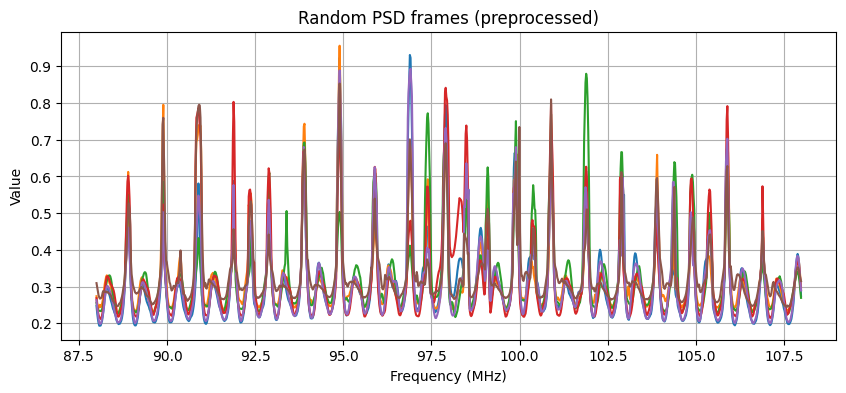

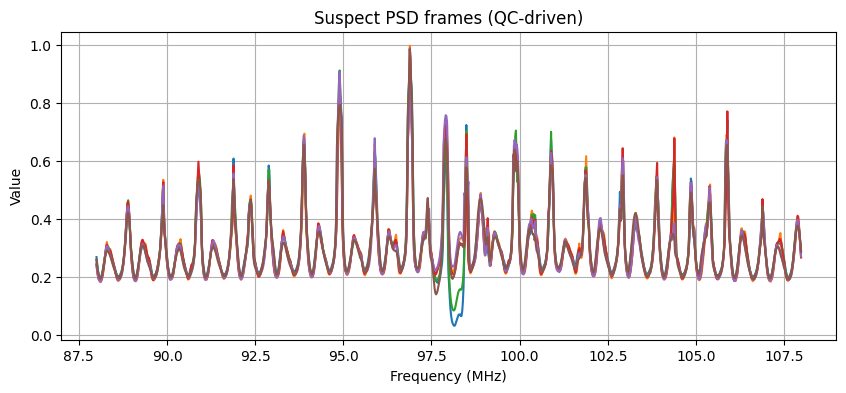

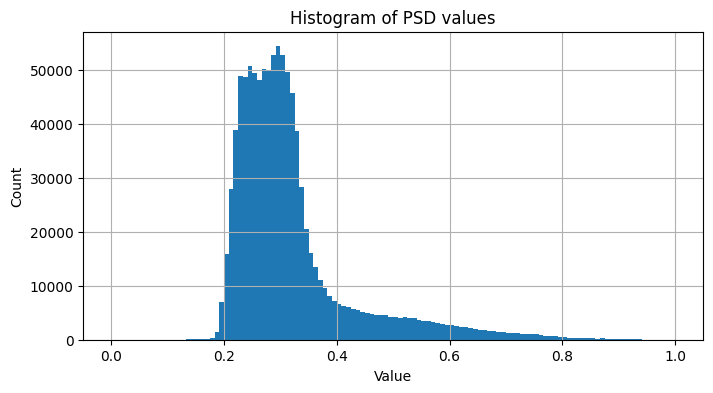

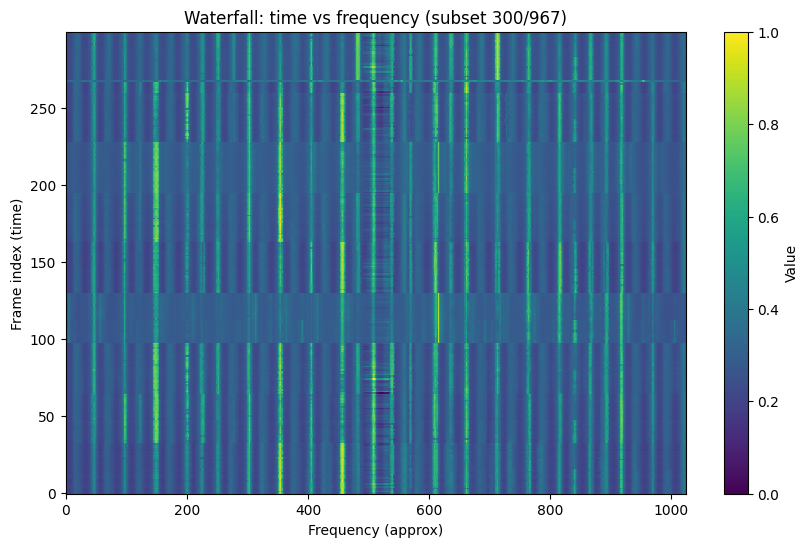

In [68]:
# ============================================================
# Cell 3 — Plot PSD examples + histogram + waterfall
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(123)

# Frequency axis for plotting
if freqs_hz is not None:
    f_axis = freqs_hz / 1e6
    x_label = "Frequency (MHz)"
else:
    f_axis = np.arange(X.shape[1], dtype=np.float32)
    x_label = "Bin index"

# 1) Random PSDs
k = min(6, X.shape[0])
rand_idx = rng.choice(X.shape[0], size=k, replace=False)

plt.figure(figsize=(10, 4))
for i in rand_idx:
    plt.plot(f_axis, X[i])
plt.title("Random PSD frames (preprocessed)")
plt.xlabel(x_label)
plt.ylabel("Value")
plt.grid(True)
plt.show()

# 2) Suspect PSDs
if len(suspect) > 0:
    k2 = min(6, len(suspect))
    plt.figure(figsize=(10, 4))
    for i in suspect[:k2]:
        plt.plot(f_axis, X[i])
    plt.title("Suspect PSD frames (QC-driven)")
    plt.xlabel(x_label)
    plt.ylabel("Value")
    plt.grid(True)
    plt.show()

# 3) Histogram
plt.figure(figsize=(8, 4))
plt.hist(X[np.isfinite(X)].ravel(), bins=120)
plt.title("Histogram of PSD values")
plt.xlabel("Value")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# 4) Waterfall (subset if too large)
max_frames_for_waterfall = 300
if X.shape[0] > max_frames_for_waterfall:
    idx_w = np.linspace(0, X.shape[0]-1, max_frames_for_waterfall).astype(int)
    W = X[idx_w]
    title_extra = f"(subset {max_frames_for_waterfall}/{X.shape[0]})"
else:
    W = X
    title_extra = ""

plt.figure(figsize=(10, 6))
plt.imshow(W, aspect="auto", interpolation="nearest", origin="lower")
plt.title(f"Waterfall: time vs frequency {title_extra}")
plt.xlabel("Frequency bin" if freqs_hz is None else "Frequency (approx)")
plt.ylabel("Frame index (time)")
plt.colorbar(label="Value")
plt.show()

In [69]:
# ============================================================
# Cell 4 — Create train/val/test split and save to Drive
#   - Time-ordered split if metadata has 'timestamp'
#   - Otherwise random split with fixed seed
# ============================================================
import json
import numpy as np
from pathlib import Path

train_ratio, val_ratio, test_ratio = 0.80, 0.10, 0.10
assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9

indices = np.arange(X.shape[0])

split_info = {"mode": None}

if meta is not None and "timestamp" in meta.columns and meta["timestamp"].notna().any():
    # Time-ordered split (recommended for temporal data)
    ts = meta["timestamp"].to_numpy()

    # Push missing timestamps to the end
    finite_ts = ts[np.isfinite(ts)]
    ts_fill = np.nanmax(finite_ts) + 1 if finite_ts.size > 0 else 0
    ts_filled = np.where(np.isfinite(ts), ts, ts_fill)

    order = np.argsort(ts_filled, kind="mergesort")
    indices_sorted = indices[order]

    n = len(indices_sorted)
    n_train = int(round(train_ratio * n))
    n_val   = int(round(val_ratio * n))

    train_idx = indices_sorted[:n_train]
    val_idx   = indices_sorted[n_train:n_train+n_val]
    test_idx  = indices_sorted[n_train+n_val:]

    split_info["mode"] = "time_ordered"
else:
    # Random split
    rng_split = np.random.default_rng(2026)
    perm = rng_split.permutation(indices)

    n = len(perm)
    n_train = int(round(train_ratio * n))
    n_val   = int(round(val_ratio * n))

    train_idx = perm[:n_train]
    val_idx   = perm[n_train:n_train+n_val]
    test_idx  = perm[n_train+n_val:]

    split_info["mode"] = "random"

split_info["n_train"] = int(train_idx.size)
split_info["n_val"]   = int(val_idx.size)
split_info["n_test"]  = int(test_idx.size)

print("=== Split summary ===")
print(split_info)
print("train_idx[:5] =", train_idx[:5])
print("val_idx[:5]   =", val_idx[:5])
print("test_idx[:5]  =", test_idx[:5])

# Save splits
splits_dir = PREP_DIR / "splits"
splits_dir.mkdir(parents=True, exist_ok=True)

np.save(splits_dir / "train_idx.npy", train_idx.astype(np.int64))
np.save(splits_dir / "val_idx.npy",   val_idx.astype(np.int64))
np.save(splits_dir / "test_idx.npy",  test_idx.astype(np.int64))

# Save a small report
report = {
    "prep_dir": str(PREP_DIR),
    "dataset_path": str(dataset_path) if dataset_path is not None else None,
    "X_shape": [int(X.shape[0]), int(X.shape[1])],
    "normalize_mode": normalize_mode,
    "global_min": float(np.nanmin(X)),
    "global_max": float(np.nanmax(X)),
    "nan_count": int(np.isnan(X).sum()),
    "inf_count": int(np.isinf(X).sum()),
    "split": split_info,
    "saved": {
        "train_idx": str(splits_dir / "train_idx.npy"),
        "val_idx":   str(splits_dir / "val_idx.npy"),
        "test_idx":  str(splits_dir / "test_idx.npy"),
    }
}

report_path = splits_dir / "split_report.json"
with open(report_path, "w") as f:
    json.dump(report, f, indent=2)

print("Saved splits to:", splits_dir)
print("Saved report:", report_path)

=== Split summary ===
{'mode': 'time_ordered', 'n_train': 774, 'n_val': 97, 'n_test': 96}
train_idx[:5] = [862 629   0 314 209]
val_idx[:5]   = [502 817 187 607 946]
test_idx[:5]  = [303 408 618 513 828]
Saved splits to: /content/drive/MyDrive/VAE/psd_normalizadas/splits
Saved report: /content/drive/MyDrive/VAE/psd_normalizadas/splits/split_report.json


# **VAE**

In [70]:
# ============================================================
# Cell 0 — Mount Drive + Load dataset (.npz) and splits
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import numpy as np

PREP_DIR = Path("/content/drive/MyDrive/VAE/psd_normalizadas")
SPLITS_DIR = PREP_DIR / "splits"

# ---- Load dataset (prefer the largest NPZ) ----
npz_files = sorted([p for p in PREP_DIR.rglob("*.npz") if p.is_file()],
                   key=lambda p: p.stat().st_size, reverse=True)
if len(npz_files) == 0:
    raise FileNotFoundError("No .npz found in PREP_DIR. Put your dataset_psd_1024_*.npz there.")

dataset_path = npz_files[0]
data = np.load(dataset_path, allow_pickle=True)

if "X" not in data:
    raise KeyError(f"NPZ keys are {list(data.keys())}. Expected key 'X'.")

X = data["X"].astype(np.float32)  # (N, 1024)
freqs_hz = data["freqs_hz"] if "freqs_hz" in data else None

print("Dataset:", dataset_path)
print("X shape:", X.shape, "dtype:", X.dtype)

# ---- Load splits ----
train_idx = np.load(SPLITS_DIR / "train_idx.npy")
val_idx   = np.load(SPLITS_DIR / "val_idx.npy")
test_idx  = np.load(SPLITS_DIR / "test_idx.npy")

print("Split sizes:", len(train_idx), len(val_idx), len(test_idx))

# ---- Create split arrays ----
X_train = X[train_idx]
X_val   = X[val_idx]
X_test  = X[test_idx]

# Conv1D expects (batch, length, channels)
X_train = X_train[..., None]
X_val   = X_val[..., None]
X_test  = X_test[..., None]

print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset: /content/drive/MyDrive/VAE/psd_normalizadas/dataset_psd_1024_norm.npz
X shape: (967, 1024) dtype: float32
Split sizes: 774 97 96
X_train: (774, 1024, 1) X_val: (97, 1024, 1) X_test: (96, 1024, 1)


In [71]:
# ============================================================
# Cell 1 — tf.data pipelines
# ============================================================
import tensorflow as tf

BATCH_SIZE = 256
AUTOTUNE = tf.data.AUTOTUNE

def make_ds(X_np, training: bool):
    ds = tf.data.Dataset.from_tensor_slices(X_np)
    if training:
        ds = ds.shuffle(min(len(X_np), 20000), seed=2026, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

ds_train = make_ds(X_train, training=True)
ds_val   = make_ds(X_val, training=False)
ds_test  = make_ds(X_test, training=False)

print("tf:", tf.__version__)

tf: 2.19.0


In [72]:
# ============================================================
# Cell 2 — VAE architecture (as proposed in the PDF)
# ============================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


LATENT_DIM = 32

try:
    Conv1DTranspose = layers.Conv1DTranspose
    HAS_CONV1D_T = True
except AttributeError:
    HAS_CONV1D_T = False

def build_decoder(latent_dim=32):
    """
    Decoder (mirror of encoder):
      z (32)
      Dense -> (256, 32)
      Up to (512, 32) then (1024, 16)
      Output: (1024, 1) sigmoid
    """
    z_in = keras.Input(shape=(latent_dim,), name="z_in")

    # Mirror feature map size: (256, 32)
    x = layers.Dense(256 * 32, name="dec_dense")(z_in)
    x = layers.Reshape((256, 32), name="dec_reshape")(x)

    if HAS_CONV1D_T:
        x = Conv1DTranspose(filters=32, kernel_size=3, strides=2, padding="same", name="dec_deconv1")(x)  # (512,32)
        x = layers.LeakyReLU(alpha=0.2, name="dec_lrelu1")(x)

        x = Conv1DTranspose(filters=16, kernel_size=5, strides=2, padding="same", name="dec_deconv2")(x)  # (1024,16)
        x = layers.LeakyReLU(alpha=0.2, name="dec_lrelu2")(x)
    else:
        x = layers.UpSampling1D(size=2, name="dec_ups1")(x)  # (512,32)
        x = layers.Conv1D(filters=32, kernel_size=3, padding="same", name="dec_conv1")(x)
        x = layers.LeakyReLU(alpha=0.2, name="dec_lrelu1")(x)

        x = layers.UpSampling1D(size=2, name="dec_ups2")(x)  # (1024,32)
        x = layers.Conv1D(filters=16, kernel_size=5, padding="same", name="dec_conv2")(x)
        x = layers.LeakyReLU(alpha=0.2, name="dec_lrelu2")(x)

    x = layers.Conv1D(filters=1, kernel_size=1, activation="sigmoid", name="x_hat")(x)
    return keras.Model(z_in, x, name="decoder")

# Recreate decoder
decoder = build_decoder(LATENT_DIM)
decoder.summary()

def build_decoder(latent_dim=32):
    z_in = keras.Input(shape=(latent_dim,), name="z_in")

    # IMPORTANT: start from (256, 32) to mirror encoder feature map
    x = layers.Dense(256 * 32, name="dec_dense")(z_in)
    x = layers.Reshape((256, 32), name="dec_reshape")(x)

    if HAS_CONV1D_T:
        x = Conv1DTranspose(filters=32, kernel_size=3, strides=2, padding="same", name="dec_deconv1")(x)  # (512,32)
        x = layers.LeakyReLU(alpha=0.2)(x)

        x = Conv1DTranspose(filters=16, kernel_size=5, strides=2, padding="same", name="dec_deconv2")(x)  # (1024,16)
        x = layers.LeakyReLU(alpha=0.2)(x)
    else:
        x = layers.UpSampling1D(size=2)(x)  # (512,32)
        x = layers.Conv1D(filters=32, kernel_size=3, padding="same")(x)
        x = layers.LeakyReLU(alpha=0.2)(x)

        x = layers.UpSampling1D(size=2)(x)  # (1024,32)
        x = layers.Conv1D(filters=16, kernel_size=5, padding="same")(x)
        x = layers.LeakyReLU(alpha=0.2)(x)

    # Output in [0,1]
    x = layers.Conv1D(filters=1, kernel_size=1, activation="sigmoid", name="x_hat")(x)
    return keras.Model(z_in, x, name="decoder")

class Sampling(layers.Layer):
    """Reparameterization trick: z = mu + sigma * eps"""
    def call(self, inputs):
        mu, logvar = inputs
        eps = tf.random.normal(shape=tf.shape(mu))
        sigma = tf.exp(0.5 * logvar)
        return mu + sigma * eps

encoder = build_encoder(LATENT_DIM)
decoder = build_decoder(LATENT_DIM)
sampler = Sampling()

encoder.summary()
decoder.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_in (InputLayer)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense (Dense)               │ (None, 8192)           │       270,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_reshape (Reshape)           │ (None, 256, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_deconv1 (Conv1DTranspose)   │ (None, 512, 32)        │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lrelu1 (LeakyReLU)          │ (None, 512, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_deconv2 (Conv1DTranspose)   │ (None, 1024, 16)       │         2,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lrelu2 (LeakyReLU)          │ (None, 1024, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ x_hat (Conv1D)                  │ (None, 1024, 1)        │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,033 (1.05 MB)

 Trainable params: 276,033 (1.05 MB)

...

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_in (InputLayer)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense (Dense)               │ (None, 8192)           │       270,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_reshape (Reshape)           │ (None, 256, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_deconv1 (Conv1DTranspose)   │ (None, 512, 32)        │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 512, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_deconv2 (Conv1DTranspose)   │ (None, 1024, 16)       │         2,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 1024, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ x_hat (Conv1D)                  │ (None, 1024, 1)        │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,033 (1.05 MB)

 Trainable params: 276,033 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

In [73]:
# ============================================================
# Patch B — VAE with beta as tf.Variable + KL warm-up callback
# ============================================================
import tensorflow as tf
from tensorflow import keras

BETA_FINAL = 1.0
BETA_WARMUP_EPOCHS = 10   # warm-up length
LR = 1e-3
EPOCHS = 50

class Sampling(keras.layers.Layer):
    def call(self, inputs):
        mu, logvar = inputs
        eps = tf.random.normal(shape=tf.shape(mu))
        sigma = tf.exp(0.5 * logvar)
        return mu + sigma * eps

sampler = Sampling()

class VAE(keras.Model):
    def __init__(self, encoder, decoder, sampler, beta_init=0.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.sampler = sampler
        self.beta = tf.Variable(beta_init, dtype=tf.float32, trainable=False, name="beta")

        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker    = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def call(self, x, training=False):
        mu, logvar = self.encoder(x, training=training)
        z = self.sampler([mu, logvar]) if training else mu  # z≈mu in inference
        return self.decoder(z, training=training)

    def train_step(self, x):
        with tf.GradientTape() as tape:
            mu, logvar = self.encoder(x, training=True)
            z = self.sampler([mu, logvar])
            x_hat = self.decoder(z, training=True)

            # Same recon term as before (MSE over bins)
            recon = tf.reduce_mean(tf.reduce_sum(tf.square(x - x_hat), axis=[1, 2]))

            # Standard diagonal Gaussian KL
            kl = -0.5 * tf.reduce_mean(tf.reduce_sum(1.0 + logvar - tf.square(mu) - tf.exp(logvar), axis=1))

            loss = recon + self.beta * kl

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.total_loss_tracker.update_state(loss)
        self.recon_loss_tracker.update_state(recon)
        self.kl_loss_tracker.update_state(kl)
        return {"loss": self.total_loss_tracker.result(),
                "recon_loss": self.recon_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result(),
                "beta": self.beta}

    def test_step(self, x):
        mu, logvar = self.encoder(x, training=False)
        z = mu
        x_hat = self.decoder(z, training=False)

        recon = tf.reduce_mean(tf.reduce_sum(tf.square(x - x_hat), axis=[1, 2]))
        kl = -0.5 * tf.reduce_mean(tf.reduce_sum(1.0 + logvar - tf.square(mu) - tf.exp(logvar), axis=1))
        loss = recon + self.beta * kl

        self.total_loss_tracker.update_state(loss)
        self.recon_loss_tracker.update_state(recon)
        self.kl_loss_tracker.update_state(kl)
        return {"loss": self.total_loss_tracker.result(),
                "recon_loss": self.recon_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result(),
                "beta": self.beta}

class BetaWarmUp(keras.callbacks.Callback):
    def __init__(self, beta_final=1.0, warmup_epochs=10):
        super().__init__()
        self.beta_final = float(beta_final)
        self.warmup_epochs = int(warmup_epochs)

    def on_epoch_begin(self, epoch, logs=None):
        if self.warmup_epochs <= 0:
            beta = self.beta_final
        else:
            t = min(1.0, epoch / float(self.warmup_epochs))
            beta = t * self.beta_final
        self.model.beta.assign(beta)

# Recreate VAE with new decoder
vae = VAE(encoder, decoder, sampler, beta_init=0.0, name="vae_psd_1024")
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=LR))

# Warm-up call so checkpointing works
_ = vae(tf.zeros((1, 1024, 1), dtype=tf.float32), training=False)
print("vae.built =", vae.built, "| beta =", float(vae.beta.numpy()))

# Callbacks
from pathlib import Path
OUT_DIR = Path("/content/drive/MyDrive/VAE/models/vae_v2_mirror_warmup")
OUT_DIR.mkdir(parents=True, exist_ok=True)

ckpt_path = str(OUT_DIR / "best.weights.h5")
callbacks = [
    BetaWarmUp(beta_final=BETA_FINAL, warmup_epochs=BETA_WARMUP_EPOCHS),
    keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True,
                                    save_weights_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, verbose=1)
]

history = vae.fit(ds_train, validation_data=ds_val, epochs=EPOCHS, callbacks=callbacks)
print("Saved best weights to:", ckpt_path)

vae.built = True | beta = 0.0
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'vae_psd_1024', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - beta: 0.0000e+00 - kl_loss: 7.0086 - loss: 44.2763 - recon_loss: 44.2763
Epoch 1: val_loss improved from inf to 22.01888, saving model to /content/drive/MyDrive/VAE/models/vae_v2_mirror_warmup/best.weights.h5
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 493ms/step - beta: 0.0000e+00 - kl_loss: 18.5128 - loss: 42.6847 - recon_loss: 42.6847 - val_beta: 0.0000e+00 - val_kl_loss: 227.0929 - val_loss: 22.0189 - val_recon_loss: 22.0189 - learning_rate: 0.0010
Epoch 2/50
3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - beta: 0.1000 - kl_loss: 200.8282 - loss: 39.7641 - recon_loss: 19.6813
Epoch 2: val_loss improved from 22.01888 to 15.11716, saving model to /content/drive/MyDrive/VAE/models/vae_v2_mirror_warmup/best.weights.h5
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step - beta: 0.1000 - kl_loss: 182.7864 - loss: 36.2681 - recon_loss: 17.9895 - val_beta: 0.1000 - val_kl_loss: 66.5361 - val_loss: 15.1172 - val_recon_loss: 8.4636 - learning_rate: 0.0010
Epoch 3/50
3/4 ━━━━━━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - beta: 1.0000 - kl_loss: 0.1212 - loss: 2.2122 - recon_loss: 2.0911
Test metrics: {'loss': <tf.Tensor: shape=(), dtype=float32, numpy=2.2122364044189453>, 'recon_loss': <tf.Tensor: shape=(), dtype=float32, numpy=2.0910613536834717>, 'kl_loss': <tf.Tensor: shape=(), dtype=float32, numpy=0.12117510288953781>, 'beta': <tf.Tensor: shape=(), dtype=float32, numpy=1.0>}


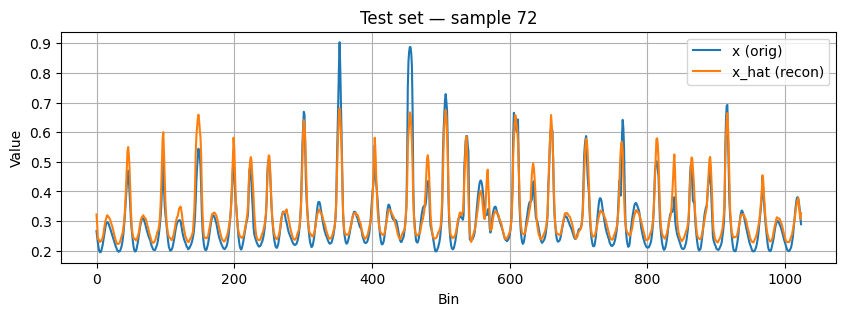

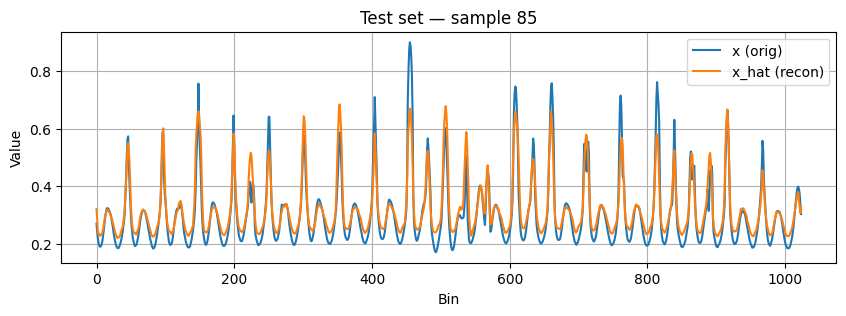

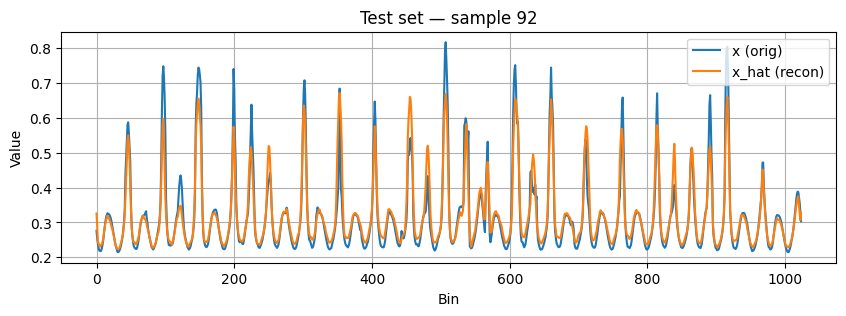

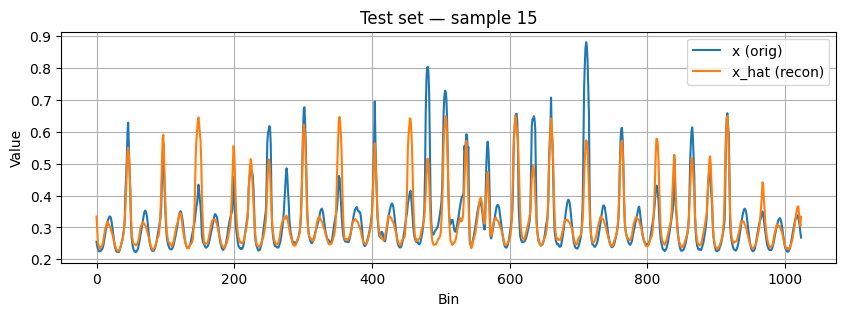

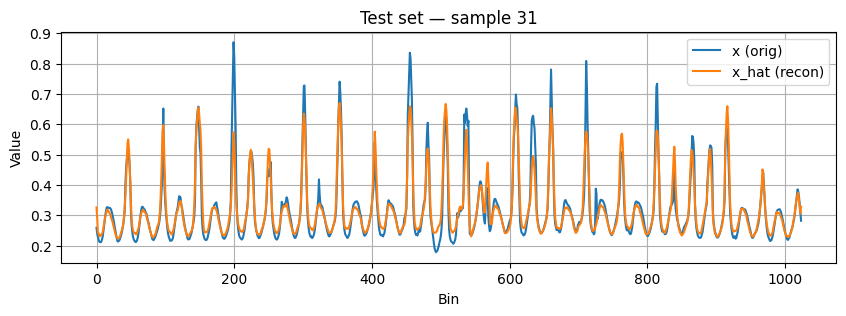

Saved encoder_mu: /content/drive/MyDrive/VAE/models/vae_v2_mirror_warmup/encoder_mu.keras
Saved decoder: /content/drive/MyDrive/VAE/models/vae_v2_mirror_warmup/decoder.keras
Saved vae: /content/drive/MyDrive/VAE/models/vae_v2_mirror_warmup/vae.keras


In [74]:
# ============================================================
# Cell 4 — Evaluate + plot reconstructions + export mu-only encoder
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

# Evaluate on test
metrics = vae.evaluate(ds_test, return_dict=True)
print("Test metrics:", metrics)

# Plot a few reconstructions
def plot_recon_examples(X_np, n=5, title="Recon examples"):
    idx = np.random.choice(X_np.shape[0], size=min(n, X_np.shape[0]), replace=False)
    X_batch = X_np[idx]
    mu, logvar = encoder.predict(X_batch, verbose=0)
    X_hat = decoder.predict(mu, verbose=0)  # deterministic inference: z=mu

    for i in range(len(idx)):
        plt.figure(figsize=(10, 3))
        plt.plot(X_batch[i, :, 0], label="x (orig)")
        plt.plot(X_hat[i, :, 0], label="x_hat (recon)")
        plt.title(f"{title} — sample {idx[i]}")
        plt.xlabel("Bin")
        plt.ylabel("Value")
        plt.grid(True)
        plt.legend()
        plt.show()

plot_recon_examples(X_test, n=5, title="Test set")

# Save mu-only encoder model (for edge inference z≈mu)
x_in = keras.Input(shape=(1024, 1), name="x_in")
mu_out, logvar_out = encoder(x_in, training=False)
encoder_mu = keras.Model(x_in, mu_out, name="encoder_mu_only")

enc_path = OUT_DIR / "encoder_mu.keras"
dec_path = OUT_DIR / "decoder.keras"
vae_path = OUT_DIR / "vae.keras"

encoder_mu.save(enc_path)
decoder.save(dec_path)
vae.save(vae_path)

print("Saved encoder_mu:", enc_path)
print("Saved decoder:", dec_path)
print("Saved vae:", vae_path)